In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

import shap
import joblib 

In [35]:
df = pd.read_csv(
    "../data/application_train.csv"
)
TARGET = "TARGET"

In [36]:
RAW_FEATURES = [

    "FLAG_MOBIL",
    "FLAG_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_EMAIL",

    "DAYS_EMPLOYED",

    "FLAG_OWN_REALTY",
    "NAME_HOUSING_TYPE",

    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "NAME_FAMILY_STATUS",

    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",

    "REG_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_WORK_CITY",
    "LIVE_CITY_NOT_WORK_CITY",

    # NEW FEATURES

    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "REGION_RATING_CLIENT"

]

In [37]:
df_model = df[
    RAW_FEATURES + ["TARGET"]
].copy()

In [38]:
for col in df_model.columns:

    if df_model[col].dtype == "object" or df_model[col].dtype == "string":

        df_model[col] = (
            df_model[col]
            .fillna("Unknown")
            .astype(str)
        )

    else:

        df_model[col] = (
            df_model[col]
            .fillna(
                df_model[col].median()
            )
        )

In [39]:
housing_default_rate = (

    df.groupby("NAME_HOUSING_TYPE")["TARGET"]

    .mean()

)

housing_map = {}

for key, value in housing_default_rate.items():

    housing_map[key] = 100 - value * 100

housing_map

{'Co-op apartment': 92.00542005420054,
 'House / apartment': 92.14724341515402,
 'Municipal apartment': 91.53540610875223,
 'Office apartment': 93.32946635730859,
 'Rented apartment': 88.1317978246961,
 'With parents': 88.17070644292521}

In [40]:
family_default_rate = (

    df.groupby("NAME_FAMILY_STATUS")["TARGET"]

    .mean()

)

family_map = {}

for key, value in family_default_rate.items():

    family_map[key] = 100 - value * 100

family_map

{'Civil marriage': 90.0607683592543,
 'Married': 92.39475619104235,
 'Separated': 91.65822094020426,
 'Single / not married': 90.11826900267715,
 'Unknown': 100.0,
 'Widow': 94.24180527186071}

In [41]:
df_model["communication_score"] = (

    df_model["FLAG_MOBIL"]

    +

    df_model["FLAG_PHONE"]

    +

    df_model["FLAG_WORK_PHONE"]

    +

    df_model["FLAG_CONT_MOBILE"]

    +

    df_model["FLAG_EMAIL"]

) * 20

In [42]:
income_default_rate = (

    df.groupby("NAME_INCOME_TYPE")["TARGET"]

    .mean()

)

income_map = {}

for key, value in income_default_rate.items():

    income_map[key] = 100 - value * 100

income_map

{'Businessman': 100.0,
 'Commercial associate': 92.41644141245119,
 'Maternity leave': 33.33333333333334,
 'Pensioner': 94.53678398125942,
 'State servant': 94.39425197410543,
 'Student': 100.0,
 'Unemployed': 62.5,
 'Working': 90.37778401556434}

In [43]:
occupation_default_rate = (

    df.groupby("OCCUPATION_TYPE")["TARGET"]

    .mean()

)

occupation_map = {}

for key, value in occupation_default_rate.items():

    occupation_map[key] = 100 - value * 100

occupation_map

{'Accountants': 95.03733665214686,
 'Cleaning staff': 90.26518966096005,
 'Cooking staff': 89.21721099015033,
 'Core staff': 93.71902667186369,
 'Drivers': 88.858650832921,
 'HR staff': 95.05813953488372,
 'High skill tech staff': 93.97622906537006,
 'IT staff': 92.57142857142857,
 'Laborers': 89.30594703206542,
 'Low-skill Laborers': 82.83475783475784,
 'Managers': 93.73426372203438,
 'Medicine staff': 93.44202234841546,
 'Private service staff': 92.98447383553767,
 'Realty agents': 92.66409266409266,
 'Sales staff': 90.11667148780252,
 'Secretaries': 93.10747663551402,
 'Security staff': 89.19972483375372,
 'Waiters/barmen staff': 88.91402714932127}

In [44]:
organization_default_rate = (

    df.groupby("ORGANIZATION_TYPE")["TARGET"]

    .mean()

)

organization_map = {}

for key, value in organization_default_rate.items():

    organization_map[key] = 100 - value * 100

organization_map

{'Advertising': 91.0394265232975,
 'Agriculture': 88.67684478371501,
 'Bank': 94.59962756052141,
 'Business Entity Type 1': 91.61306920504245,
 'Business Entity Type 2': 91.0360884749709,
 'Business Entity Type 3': 90.7265968232511,
 'Cleaning': 91.32947976878613,
 'Construction': 88.65232163080408,
 'Culture': 93.75,
 'Electricity': 93.65853658536585,
 'Emergency': 92.55014326647564,
 'Government': 93.04844138738476,
 'Hotel': 93.7888198757764,
 'Housing': 91.84526921066387,
 'Industry: type 1': 89.56780923994039,
 'Industry: type 10': 94.28571428571429,
 'Industry: type 11': 91.03963239517519,
 'Industry: type 12': 97.15447154471545,
 'Industry: type 13': 90.2439024390244,
 'Industry: type 2': 91.55844155844156,
 'Industry: type 3': 89.6244131455399,
 'Industry: type 4': 89.52879581151832,
 'Industry: type 5': 92.48704663212435,
 'Industry: type 6': 92.95774647887323,
 'Industry: type 7': 92.33490566037736,
 'Industry: type 8': 81.25,
 'Industry: type 9': 92.8119349005425,
 'Insuranc

In [45]:
employment_years = (
    abs(df_model["DAYS_EMPLOYED"])/ 365
)

df_model["employment_stability_score"] = (
    np.clip(employment_years,0,20)/ 20* 100
)

In [46]:
df_model["housing_stability_score"] = (

    df_model["NAME_HOUSING_TYPE"]

    .map(housing_map)

    .fillna(

        np.mean(

            list(

                housing_map.values()

            )

        )

    )

)

In [47]:
family_ratio = (

    df_model["CNT_CHILDREN"]

    /

    np.maximum(

        df_model["CNT_FAM_MEMBERS"],

        1

    )

)

df_model["family_stability_score"] = (

    100

    -

    family_ratio * 100

)

df_model["family_stability_score"] += (

    df_model["NAME_FAMILY_STATUS"]

    .map(family_map)

    .fillna(50)

)

df_model["family_stability_score"] /= 2

In [48]:
registration_years = (

    abs(df_model["DAYS_REGISTRATION"])

    / 365

)

id_years = (

    abs(df_model["DAYS_ID_PUBLISH"])

    / 365

)

phone_years = (

    abs(df_model["DAYS_LAST_PHONE_CHANGE"])

    / 365

)

df_model["identity_consistency_score"] = (

    np.clip(

        registration_years

        +

        id_years

        +

        phone_years,

        0,

        30

    )

    / 30

    * 100

)

In [49]:
regional_changes = (

    df_model["REG_REGION_NOT_WORK_REGION"]

    +

    df_model["REG_CITY_NOT_WORK_CITY"]

    +

    df_model["LIVE_CITY_NOT_WORK_CITY"]

)

df_model["regional_stability_score"] = (

    100

    -

    regional_changes * 33.33

)
education_default_rate = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .mean()
)

education_map = {}

for key, value in education_default_rate.items():
    education_map[key] = 100 - value * 100

education_map

{'Academic degree': 97.84946236559139,
 'Higher education': 94.7340371015681,
 'Incomplete higher': 91.3728990034211,
 'Lower secondary': 88.801261829653,
 'Secondary / secondary special': 90.97252107658119}

In [50]:
df_model["education_stability_score"] = (

    df_model["NAME_EDUCATION_TYPE"]

    .map(education_map)

    .fillna(50)

)

df_model["income_stability_score"] = (

    df_model["NAME_INCOME_TYPE"]

    .map(income_map)

    .fillna(50)

)

df_model["occupation_stability_score"] = (

    df_model["OCCUPATION_TYPE"]

    .map(occupation_map)

    .fillna(50)

)

df_model["regional_quality_score"] = (

    df_model["REGION_RATING_CLIENT"]

    .replace({

        1: 100,
        2: 70,
        3: 40

    })

)

organization_default_rate = (
    df.groupby("ORGANIZATION_TYPE")["TARGET"]
    .mean()
)

organization_map = {}

for key, value in organization_default_rate.items():
    organization_map[key] = 100 - value * 100

df_model["organization_stability_score"] = (
    df_model["ORGANIZATION_TYPE"]
    .map(organization_map)
    .fillna(50)
)

In [51]:
FEATURES = [

    "communication_score",

    "employment_stability_score",

    "housing_stability_score",

    "family_stability_score",

    "identity_consistency_score",

    "regional_stability_score",

    "education_stability_score",

    "income_stability_score",

    "occupation_stability_score",

    "organization_stability_score",

    "regional_quality_score"

]

In [52]:
digital_maps = {
    "housing": housing_map,
    "family": family_map,
    "education": education_map,
    "income": income_map,
    "occupation": occupation_map,
    "organization": organization_map
}

In [53]:
print("organization_stability_score" in df_model.columns)

True


In [54]:
X = df_model[FEATURES]

y = df_model["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [55]:
model = XGBClassifier(

    max_depth=4,

    learning_rate=0.05,

    n_estimators=300,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"

)

model.fit(

    X_train,

    y_train

)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [56]:
prob = model.predict_proba(

    X_test

)[:,1]

thresholds = np.arange(

    0.2,

    0.6,

    0.01

)

best_threshold = 0
best_f1 = 0

for t in thresholds:

    pred = (

        prob >= t

    ).astype(int)

    score = f1_score(

        y_test,

        pred

    )

    if score > best_f1:

        best_f1 = score
        best_threshold = t

print(best_threshold)
print(best_f1)

0.2
0.08110137672090113


In [57]:
pred = (

    prob >= best_threshold

).astype(int)

print("Accuracy :", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall   :", recall_score(y_test,pred))
print("F1 Score :", f1_score(y_test,pred))
print("ROC AUC  :", roc_auc_score(y_test,prob))

Accuracy : 0.9081721990144332
Precision: 0.2162883845126836
Recall   : 0.04990757855822551
F1 Score : 0.08110137672090113
ROC AUC  : 0.6471020690919158


In [58]:
digital_trust_index = (

    (1 - prob)

    * 100

)

digital_trust_index[:10]

array([90.15453, 92.58006, 95.41764, 95.37085, 95.41764, 87.69004,
       93.50394, 96.0863 , 89.22515, 92.8511 ], dtype=float32)

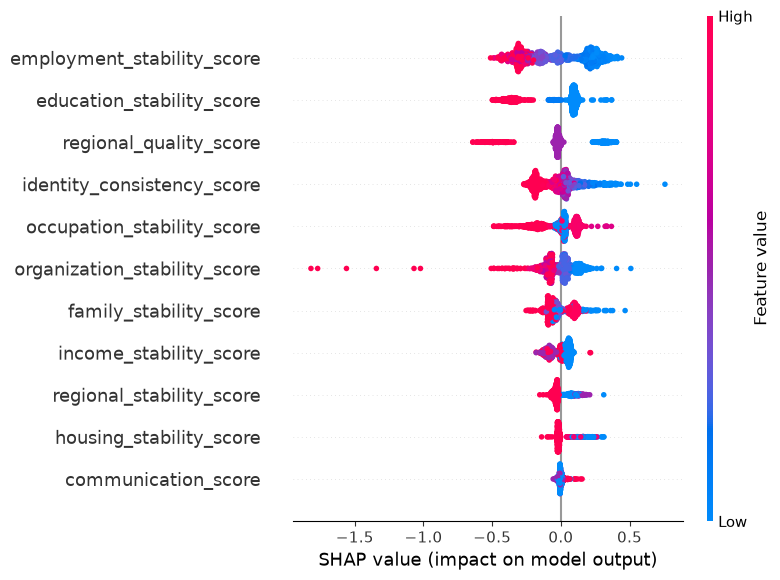

In [59]:
explainer = shap.TreeExplainer(model)

sample = X_test.sample(

    min(1000, len(X_test)),

    random_state=42

)

shap_values = explainer.shap_values(sample)

shap.summary_plot(

    shap_values,

    sample

)

In [60]:
joblib.dump(
    model,
    "../models/digital_trust_model.pkl"
)

joblib.dump(
    FEATURES,
    "../models/digital_trust_features.pkl"
)

joblib.dump(
    best_threshold,
    "../models/digital_trust_threshold.pkl"
)

import joblib

digital_maps = {
    "housing": housing_map,
    "family": family_map,
    "education": education_map,
    "income": income_map,
    "occupation": occupation_map,
    "organization": organization_map
}

joblib.dump(
    digital_maps,
    "../models/digital_trust_maps.pkl"
)

import shap
import joblib

explainer = shap.TreeExplainer(model)

joblib.dump(
    explainer,
    "../models/digital_trust_shap.pkl"
)

['../models/digital_trust_shap.pkl']